# [8.2] Attribution Patching and EAP - Solutions

```python
GT_TIER = "GT-1"
EXERCISE_ID = "8_2_attribution_patching_and_eap"
EXPECTED_RUNTIME = "90-120 minutes for exercises; minutes on the CUDA preflight"
REQUIRES_GPU = True  # the planted learner theorem runs on CPU; full verification includes CUDA
```

## Core Question

When can a gradient cheaply identify the same causal nodes and edges as exact patching, and what failure does path integration repair?

**By the end of this notebook, you will have shown that corrupt-point attribution misses a causally important threshold-gated route in a planted nonlinear graph, while integrated gradients recovers its top-k ranking and path-completeness before you trust either method on a transformer.**

The cold open is a four-sender, four-receiver computation. `relation gate -> threshold gate` changes the answer score by **1.40** when patched exactly. At the corrupt input, however, that receiver is below threshold, its gradient is exactly zero, and ordinary attribution assigns the edge **0.00**. This is not noise: it is a known nonlinear false negative.

You will keep exact intervention as ground truth, implement each approximation yourself, and finish with one labeled signature figure comparing:

- exact node patching vs first-order attribution vs integrated gradients;
- exact edge patching vs EAP vs EAP-IG;
- correlation, top-k overlap, path-conservation error, a linear positive control, a zero-effect edge, and a shuffled-delta control.

## Learning Objectives

1. Define clean and corrupt runs on a graph whose mechanism is fully known.
2. Implement exact single-node and single-edge patching.
3. Derive attribution patching from a first-order Taylor approximation.
4. Integrate gradients along the corrupt-to-clean path.
5. Implement EAP and EAP-IG at edge level.
6. Separate ranking agreement, path completeness, and computational cost.
7. Find and explain a false negative instead of hiding it in an aggregate metric.

The toy graph is the theorem. The pinned TransformerLens `gelu-1l` CUDA experiment at the end is only a mechanics bridge to real hooks and logits; it is not the evidence for the nonlinear claim.

<details>
<summary>Common bug - evaluating every gradient at the corrupt endpoint</summary>

EAP-IG must average gradients along the full corrupt-to-clean path before multiplying by the activation delta. Repeating the endpoint gradient at every step leaves the threshold-gated false negative unchanged.

</details>

The committed `verification_report.json` records the serialized CUDA preflight as supporting evidence; the learner result above is recomputed from the visible implementation.


In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch as t
from IPython.display import Markdown, display

chapter = "chapter8_automated_circuits"
section = "part2_attribution_patching_eap"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
section_dir = root_dir / chapter / "exercises" / section
assets_dir = root_dir / chapter / "instructions" / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from chapter8_automated_circuits.exercises.part2_attribution_patching_eap import tests

t.set_default_dtype(t.float64)
t.manual_seed(0)


def _require_finite_tensor(tensor: t.Tensor, name: str) -> None:
    if not t.isfinite(tensor).all():
        raise ValueError(f"{name} must be finite.")


## 1. Build a mechanism you can audit

### Exercise 1 - implement the planted graph and metric

> **Difficulty:** medium | **Importance:** essential | **Time:** 15 minutes

`weights[receiver, sender]` defines four named routes. The metric has three terms: linear answer evidence, a squared ReLU threshold gate, and a saturating context read. The fourth receiver is deliberately unused.

Implement the constructor and both forward functions. Do not detach tensors: later exercises need autograd through the same computation.


In [2]:
@dataclass(frozen=True)
class PlantedAttributionGraph:
    """A tiny nonlinear graph with an exact, human-readable edge ground truth."""

    sender_labels: tuple[str, ...]
    receiver_labels: tuple[str, ...]
    weights: t.Tensor
    clean_sender: t.Tensor
    corrupt_sender: t.Tensor
    gate_strength: float
    gate_threshold: float

def make_planted_attribution_graph(
    *,
    gate_strength: float = 1.4,
    gate_threshold: float = 1.0,
) -> PlantedAttributionGraph:
    """Build the exact toy graph used throughout the learner-facing section."""

    if gate_strength <= 0:
        raise ValueError("gate_strength must be positive.")
    if gate_threshold <= 0:
        raise ValueError("gate_threshold must be positive.")
    weights = t.tensor(
        [
            [1.10, 0.00, 0.25, 0.00],
            [0.00, 2.00, 0.25, 0.00],
            [0.15, 0.00, 0.80, 0.00],
            [0.00, 0.00, 0.00, 0.70],
        ],
        dtype=t.float64,
    )
    return PlantedAttributionGraph(
        sender_labels=("name copy", "relation gate", "context", "decoy"),
        receiver_labels=("answer evidence", "threshold gate", "context read", "unused monitor"),
        weights=weights,
        clean_sender=t.ones(4, dtype=t.float64),
        corrupt_sender=t.zeros(4, dtype=t.float64),
        gate_strength=float(gate_strength),
        gate_threshold=float(gate_threshold),
    )

def _validate_sender(graph: PlantedAttributionGraph, sender: t.Tensor) -> None:
    if sender.shape != graph.clean_sender.shape:
        raise ValueError("sender must match the planted sender shape.")
    _require_finite_tensor(sender, "sender")

def toy_metric_from_receivers(
    graph: PlantedAttributionGraph,
    receivers: t.Tensor,
) -> t.Tensor:
    """Score evidence, a nonlinear threshold route, and contextual support."""

    if receivers.shape != (len(graph.receiver_labels),):
        raise ValueError("receivers must have one value per receiver node.")
    _require_finite_tensor(receivers, "receivers")
    gated = t.relu(receivers[1] - graph.gate_threshold).square()
    return 1.2 * receivers[0] + graph.gate_strength * gated + 0.8 * t.tanh(receivers[2])

def toy_metric(graph: PlantedAttributionGraph, sender: t.Tensor) -> t.Tensor:
    """Run sender activations through the planted graph and return its scalar score."""

    _validate_sender(graph, sender)
    return toy_metric_from_receivers(graph, graph.weights @ sender)

tests.test_make_planted_graph_has_exact_ground_truth(
    make_planted_attribution_graph, toy_metric
)

Planted graph ground truth passed: clean-corrupt metric = 4.399326.


<details>
<summary>Expected output</summary>

`clean metric = 4.399326`, `corrupt metric = 0.0`, and the ground-truth test passes.

</details>

<details>
<summary>Help - first things to check</summary>

Write the receiver vector as `graph.weights @ sender`. The nonlinear term is `gate_strength * relu(receiver[1] - threshold) ** 2`.

</details>

<details>
<summary>Interpretation</summary>

The clean-corrupt gap is not itself an attribution. It is the total behavioral change that node and edge methods will try to explain.

</details>

<details>
<summary>Solution</summary>

```python
@dataclass(frozen=True)
class PlantedAttributionGraph:
    """A tiny nonlinear graph with an exact, human-readable edge ground truth."""

    sender_labels: tuple[str, ...]
    receiver_labels: tuple[str, ...]
    weights: t.Tensor
    clean_sender: t.Tensor
    corrupt_sender: t.Tensor
    gate_strength: float
    gate_threshold: float

def make_planted_attribution_graph(
    *,
    gate_strength: float = 1.4,
    gate_threshold: float = 1.0,
) -> PlantedAttributionGraph:
    """Build the exact toy graph used throughout the learner-facing section."""

    if gate_strength <= 0:
        raise ValueError("gate_strength must be positive.")
    if gate_threshold <= 0:
        raise ValueError("gate_threshold must be positive.")
    weights = t.tensor(
        [
            [1.10, 0.00, 0.25, 0.00],
            [0.00, 2.00, 0.25, 0.00],
            [0.15, 0.00, 0.80, 0.00],
            [0.00, 0.00, 0.00, 0.70],
        ],
        dtype=t.float64,
    )
    return PlantedAttributionGraph(
        sender_labels=("name copy", "relation gate", "context", "decoy"),
        receiver_labels=("answer evidence", "threshold gate", "context read", "unused monitor"),
        weights=weights,
        clean_sender=t.ones(4, dtype=t.float64),
        corrupt_sender=t.zeros(4, dtype=t.float64),
        gate_strength=float(gate_strength),
        gate_threshold=float(gate_threshold),
    )

def _validate_sender(graph: PlantedAttributionGraph, sender: t.Tensor) -> None:
    if sender.shape != graph.clean_sender.shape:
        raise ValueError("sender must match the planted sender shape.")
    _require_finite_tensor(sender, "sender")

def toy_metric_from_receivers(
    graph: PlantedAttributionGraph,
    receivers: t.Tensor,
) -> t.Tensor:
    """Score evidence, a nonlinear threshold route, and contextual support."""

    if receivers.shape != (len(graph.receiver_labels),):
        raise ValueError("receivers must have one value per receiver node.")
    _require_finite_tensor(receivers, "receivers")
    gated = t.relu(receivers[1] - graph.gate_threshold).square()
    return 1.2 * receivers[0] + graph.gate_strength * gated + 0.8 * t.tanh(receivers[2])

def toy_metric(graph: PlantedAttributionGraph, sender: t.Tensor) -> t.Tensor:
    """Run sender activations through the planted graph and return its scalar score."""

    _validate_sender(graph, sender)
    return toy_metric_from_receivers(graph, graph.weights @ sender)
```

</details>

## 2. Exact node patching is the reference experiment

### Exercise 2 - implement `exact_node_patch_effects`

> **Difficulty:** easy | **Importance:** essential | **Time:** 10 minutes

Start from the corrupt sender vector. For each sender index, replace only that coordinate with its clean value and measure `patched_metric - corrupt_metric`.

This is a causal intervention on one node. It is deliberately expensive: one forward evaluation per candidate node.


In [3]:
def exact_node_patch_effects(graph: PlantedAttributionGraph) -> t.Tensor:
    """Patch one clean sender node at a time into the corrupt run."""

    baseline = toy_metric(graph, graph.corrupt_sender)
    effects = []
    for index in range(graph.clean_sender.numel()):
        patched = graph.corrupt_sender.clone()
        patched[index] = graph.clean_sender[index]
        effects.append(toy_metric(graph, patched) - baseline)
    return t.stack(effects)

tests.test_exact_node_patching_recovers_known_effects(exact_node_patch_effects)

Exact node patching passed: the gated route is important and the decoy is null.


<details>
<summary>Expected output</summary>

Exact effects are approximately `[1.4391, 1.4000, 0.8312, 0.0000]`.

</details>

<details>
<summary>Help - first things to check</summary>

Clone `corrupt_sender` inside the loop. Reusing a mutated tensor accidentally patches several nodes at once.

</details>

<details>
<summary>Interpretation</summary>

The relation gate is nearly tied for the largest effect, while the decoy is an exact negative control. These are the labels an approximation must recover.

</details>

<details>
<summary>Solution</summary>

```python
def exact_node_patch_effects(graph: PlantedAttributionGraph) -> t.Tensor:
    """Patch one clean sender node at a time into the corrupt run."""

    baseline = toy_metric(graph, graph.corrupt_sender)
    effects = []
    for index in range(graph.clean_sender.numel()):
        patched = graph.corrupt_sender.clone()
        patched[index] = graph.clean_sender[index]
        effects.append(toy_metric(graph, patched) - baseline)
    return t.stack(effects)
```

</details>

## 3. First-order attribution can be confidently wrong

### Exercise 3 - implement corrupt-point attribution patching

> **Difficulty:** medium | **Importance:** essential | **Time:** 10 minutes

Attribution patching uses one backward pass at the corrupt activation:

\[
\widehat{\Delta m_i} = (a_i^{clean} - a_i^{corrupt})
\frac{\partial m}{\partial a_i}\bigg|_{a^{corrupt}}.
\]

Use `torch.autograd.grad`; do not finite-difference or call exact patching inside the approximation.


In [4]:
def first_order_node_attribution(graph: PlantedAttributionGraph) -> t.Tensor:
    """Compute corrupt-point attribution for each sender node."""

    sender = graph.corrupt_sender.clone().requires_grad_(True)
    gradient = t.autograd.grad(toy_metric(graph, sender), sender)[0]
    return (graph.clean_sender - graph.corrupt_sender) * gradient

tests.test_first_order_attribution_exposes_nonlinear_false_negative(
    first_order_node_attribution
)

First-order attribution passed: it visibly misses the threshold-gated route.


<details>
<summary>Expected output</summary>

Attribution scores are `[1.44, 0.00, 0.94, 0.00]`; the important relation-gate node is assigned zero.

</details>

<details>
<summary>Help - first things to check</summary>

Create `sender = corrupt_sender.clone().requires_grad_(True)`, differentiate the scalar metric with respect to it, then multiply by the clean-corrupt delta.

</details>

<details>
<summary>Interpretation</summary>

The zero is a structural false negative. The corrupt state lies below a ReLU threshold, so a local derivative cannot see the route that turns on farther along the path.

</details>

<details>
<summary>Solution</summary>

```python
def first_order_node_attribution(graph: PlantedAttributionGraph) -> t.Tensor:
    """Compute corrupt-point attribution for each sender node."""

    sender = graph.corrupt_sender.clone().requires_grad_(True)
    gradient = t.autograd.grad(toy_metric(graph, sender), sender)[0]
    return (graph.clean_sender - graph.corrupt_sender) * gradient
```

</details>

## 4. Integrate through the gate

### Exercise 4 - implement path gradients and integrated node scores

> **Difficulty:** hard | **Importance:** essential | **Time:** 20 minutes

Sample midpoint activations along `corrupt + alpha * (clean - corrupt)`, differentiate at every point, average the gradients, and multiply by the full activation delta.

Midpoints avoid over-weighting the path endpoints. With enough steps, the sum of integrated-gradient scores should recover the full clean-corrupt metric change. That completeness property does **not** imply that each score equals a single-node patch effect when nodes interact.


In [5]:
def sender_path_gradients(
    graph: PlantedAttributionGraph,
    *,
    steps: int = 64,
) -> t.Tensor:
    """Evaluate sender gradients at midpoint samples on the corrupt-clean path."""

    if steps <= 0:
        raise ValueError("steps must be positive.")
    delta = graph.clean_sender - graph.corrupt_sender
    gradients = []
    for alpha in (t.arange(steps, dtype=t.float64) + 0.5) / steps:
        sender = (graph.corrupt_sender + alpha * delta).detach().requires_grad_(True)
        gradients.append(t.autograd.grad(toy_metric(graph, sender), sender)[0])
    return t.stack(gradients)

def integrated_gradient_node_scores(
    graph: PlantedAttributionGraph,
    *,
    steps: int = 64,
) -> t.Tensor:
    """Compute per-sender integrated-gradient scores along the joint path."""

    path_gradients = sender_path_gradients(graph, steps=steps)
    return (graph.clean_sender - graph.corrupt_sender) * path_gradients.mean(dim=0)

tests.test_integrated_gradients_recovers_ranking_and_completeness(
    sender_path_gradients, integrated_gradient_node_scores
)

Integrated gradients passed: top-2 ranking recovered and completeness error < 5e-4.


<details>
<summary>Expected output</summary>

IG scores are about `[1.4134, 1.9441, 1.0414, 0.0000]`; their sum is within `5e-4` of `4.399326` and top-2 overlap with exact patching is `1.0`.

</details>

<details>
<summary>Help - first things to check</summary>

Each interpolation point must be a fresh leaf tensor with `requires_grad_(True)`. Stack the gradients to shape `[steps, n_senders]`.

</details>

<details>
<summary>Interpretation</summary>

IG recovers the hidden route, but allocates part of the threshold interaction to context. Exact patching and path attribution answer related, not identical, causal questions.

</details>

<details>
<summary>Solution</summary>

```python
def sender_path_gradients(
    graph: PlantedAttributionGraph,
    *,
    steps: int = 64,
) -> t.Tensor:
    """Evaluate sender gradients at midpoint samples on the corrupt-clean path."""

    if steps <= 0:
        raise ValueError("steps must be positive.")
    delta = graph.clean_sender - graph.corrupt_sender
    gradients = []
    for alpha in (t.arange(steps, dtype=t.float64) + 0.5) / steps:
        sender = (graph.corrupt_sender + alpha * delta).detach().requires_grad_(True)
        gradients.append(t.autograd.grad(toy_metric(graph, sender), sender)[0])
    return t.stack(gradients)

def integrated_gradient_node_scores(
    graph: PlantedAttributionGraph,
    *,
    steps: int = 64,
) -> t.Tensor:
    """Compute per-sender integrated-gradient scores along the joint path."""

    path_gradients = sender_path_gradients(graph, steps=steps)
    return (graph.clean_sender - graph.corrupt_sender) * path_gradients.mean(dim=0)
```

</details>

## 5. Move from nodes to edges

### Exercise 5 - implement exact edge patching

> **Difficulty:** hard | **Importance:** high | **Time:** 20 minutes

An edge contribution is `weight[receiver, sender] * sender_delta[sender]`. Patch one such contribution into the corrupt receiver vector, leaving every other edge corrupt.

Return matrices shaped `[sender, receiver]`. This orientation keeps rows readable as information sources and columns as destinations.


In [6]:
def planted_edge_deltas(graph: PlantedAttributionGraph) -> t.Tensor:
    """Return clean-corrupt contributions for every sender-to-receiver edge."""

    sender_delta = graph.clean_sender - graph.corrupt_sender
    return graph.weights.T * sender_delta[:, None]

def exact_edge_patch_effects(graph: PlantedAttributionGraph) -> t.Tensor:
    """Patch one clean edge contribution at a time into corrupt receivers."""

    corrupt_receivers = graph.weights @ graph.corrupt_sender
    baseline = toy_metric_from_receivers(graph, corrupt_receivers)
    edge_deltas = planted_edge_deltas(graph)
    effects = t.empty_like(edge_deltas)
    for sender_index in range(edge_deltas.shape[0]):
        for receiver_index in range(edge_deltas.shape[1]):
            patched = corrupt_receivers.clone()
            patched[receiver_index] += edge_deltas[sender_index, receiver_index]
            effects[sender_index, receiver_index] = (
                toy_metric_from_receivers(graph, patched) - baseline
            )
    return effects

tests.test_exact_edge_patching_matches_planted_matrix(
    planted_edge_deltas, exact_edge_patch_effects
)

Exact edge patching passed: relation gate -> threshold gate is the top edge.


<details>
<summary>Expected output</summary>

The top exact edge is `relation gate -> threshold gate` with effect `1.40`; every edge into `unused monitor` has effect zero.

</details>

<details>
<summary>Help - first things to check</summary>

Transpose the weight matrix after multiplying by the sender delta. In the nested loop, add only `edge_delta[sender, receiver]` to one corrupt receiver coordinate.

</details>

<details>
<summary>Interpretation</summary>

Edge patching identifies a route rather than merely a component. The exact zero column is a built-in control against attractive but meaningless heatmap structure.

</details>

<details>
<summary>Solution</summary>

```python
def planted_edge_deltas(graph: PlantedAttributionGraph) -> t.Tensor:
    """Return clean-corrupt contributions for every sender-to-receiver edge."""

    sender_delta = graph.clean_sender - graph.corrupt_sender
    return graph.weights.T * sender_delta[:, None]

def exact_edge_patch_effects(graph: PlantedAttributionGraph) -> t.Tensor:
    """Patch one clean edge contribution at a time into corrupt receivers."""

    corrupt_receivers = graph.weights @ graph.corrupt_sender
    baseline = toy_metric_from_receivers(graph, corrupt_receivers)
    edge_deltas = planted_edge_deltas(graph)
    effects = t.empty_like(edge_deltas)
    for sender_index in range(edge_deltas.shape[0]):
        for receiver_index in range(edge_deltas.shape[1]):
            patched = corrupt_receivers.clone()
            patched[receiver_index] += edge_deltas[sender_index, receiver_index]
            effects[sender_index, receiver_index] = (
                toy_metric_from_receivers(graph, patched) - baseline
            )
    return effects
```

</details>

## 6. EAP and EAP-IG

### Exercise 6 - implement edge attribution and path-integrated edge attribution

> **Difficulty:** hard | **Importance:** essential | **Time:** 25 minutes

EAP pairs each sender-to-receiver edge delta with the downstream gradient:

\[
\widehat{\Delta m_{u \to v}} = \Delta e_{u \to v}
\frac{\partial m}{\partial r_v}.
\]

Ordinary EAP uses the corrupt receiver gradient once. EAP-IG averages receiver gradients along the full corrupt-clean path. Implement the path sampler and the elementwise edge score.


In [7]:
def receiver_path_gradients(
    graph: PlantedAttributionGraph,
    *,
    steps: int = 64,
) -> t.Tensor:
    """Evaluate metric gradients with respect to receiver nodes along the path."""

    if steps <= 0:
        raise ValueError("steps must be positive.")
    corrupt = graph.weights @ graph.corrupt_sender
    clean = graph.weights @ graph.clean_sender
    delta = clean - corrupt
    gradients = []
    for alpha in (t.arange(steps, dtype=t.float64) + 0.5) / steps:
        receivers = (corrupt + alpha * delta).detach().requires_grad_(True)
        gradients.append(
            t.autograd.grad(toy_metric_from_receivers(graph, receivers), receivers)[0]
        )
    return t.stack(gradients)

def eap_edge_scores(
    edge_deltas: t.Tensor,
    receiver_gradients: t.Tensor,
) -> t.Tensor:
    """Multiply every edge delta by the downstream receiver gradient."""

    if edge_deltas.ndim != 2:
        raise ValueError("edge_deltas must have shape (sender, receiver).")
    if receiver_gradients.shape != (edge_deltas.shape[1],):
        raise ValueError("receiver_gradients must have one value per receiver.")
    _require_finite_tensor(edge_deltas, "edge_deltas")
    _require_finite_tensor(receiver_gradients, "receiver_gradients")
    return edge_deltas * receiver_gradients[None, :]

def corrupt_receiver_gradients(graph: PlantedAttributionGraph) -> t.Tensor:
    """Return downstream gradients at the corrupt receiver state."""

    receivers = (graph.weights @ graph.corrupt_sender).detach().requires_grad_(True)
    return t.autograd.grad(toy_metric_from_receivers(graph, receivers), receivers)[0]

tests.test_eap_and_eap_ig_separate_speed_from_faithfulness(
    receiver_path_gradients, eap_edge_scores, corrupt_receiver_gradients
)

EAP comparison passed: IG raises top-3 overlap from 2/3 to 1.0.


<details>
<summary>Expected output</summary>

Plain EAP gives the threshold edge `0.00` and top-3 overlap `2/3`; EAP-IG gives it about `1.944`, top-3 overlap `1.0`, and correlation above `0.97`.

</details>

<details>
<summary>Help - first things to check</summary>

Differentiate with respect to the receiver vector, not the sender. Broadcast the receiver gradient across sender rows with `receiver_gradients[None, :]`.

</details>

<details>
<summary>Interpretation</summary>

EAP is the cheap screen: one backward pass. EAP-IG spends `steps` backward passes to inspect gradient changes along the path. Neither replaces exact patches on the shortlisted edges.

</details>

<details>
<summary>Solution</summary>

```python
def receiver_path_gradients(
    graph: PlantedAttributionGraph,
    *,
    steps: int = 64,
) -> t.Tensor:
    """Evaluate metric gradients with respect to receiver nodes along the path."""

    if steps <= 0:
        raise ValueError("steps must be positive.")
    corrupt = graph.weights @ graph.corrupt_sender
    clean = graph.weights @ graph.clean_sender
    delta = clean - corrupt
    gradients = []
    for alpha in (t.arange(steps, dtype=t.float64) + 0.5) / steps:
        receivers = (corrupt + alpha * delta).detach().requires_grad_(True)
        gradients.append(
            t.autograd.grad(toy_metric_from_receivers(graph, receivers), receivers)[0]
        )
    return t.stack(gradients)

def eap_edge_scores(
    edge_deltas: t.Tensor,
    receiver_gradients: t.Tensor,
) -> t.Tensor:
    """Multiply every edge delta by the downstream receiver gradient."""

    if edge_deltas.ndim != 2:
        raise ValueError("edge_deltas must have shape (sender, receiver).")
    if receiver_gradients.shape != (edge_deltas.shape[1],):
        raise ValueError("receiver_gradients must have one value per receiver.")
    _require_finite_tensor(edge_deltas, "edge_deltas")
    _require_finite_tensor(receiver_gradients, "receiver_gradients")
    return edge_deltas * receiver_gradients[None, :]

def corrupt_receiver_gradients(graph: PlantedAttributionGraph) -> t.Tensor:
    """Return downstream gradients at the corrupt receiver state."""

    receivers = (graph.weights @ graph.corrupt_sender).detach().requires_grad_(True)
    return t.autograd.grad(toy_metric_from_receivers(graph, receivers), receivers)[0]
```

</details>

## 7. Grade the approximation, not the picture

### Exercise 7 - implement agreement diagnostics

> **Difficulty:** medium | **Importance:** essential | **Time:** 15 minutes

Implement three independent checks:

1. Pearson correlation over all signed scores.
2. Overlap between the largest-magnitude top-k sets.
3. Mean absolute error and explicit false-negative indices.

A smooth-looking heatmap can still put the wrong edges in the top-k. Never accept one aggregate metric as sufficient.


In [8]:
@dataclass(frozen=True)
class AgreementMetrics:
    correlation: float
    topk_overlap: float
    mean_absolute_error: float
    false_negative_indices: tuple[int, ...]

def agreement_metrics(
    exact_scores: t.Tensor,
    approx_scores: t.Tensor,
    *,
    top_k: int,
    false_negative_threshold: float = 0.5,
) -> AgreementMetrics:
    """Measure ranking agreement and distinguish it from completeness."""

    exact = exact_scores.flatten().to(dtype=t.float64)
    approx = approx_scores.flatten().to(dtype=t.float64)
    if exact.shape != approx.shape or exact.numel() < 2:
        raise ValueError("exact_scores and approx_scores must match and contain two values.")
    if not 0 < top_k <= exact.numel():
        raise ValueError("top_k must index at least one available score.")
    _require_finite_tensor(exact, "exact_scores")
    _require_finite_tensor(approx, "approx_scores")
    centered_exact = exact - exact.mean()
    centered_approx = approx - approx.mean()
    denom = centered_exact.norm() * centered_approx.norm()
    correlation = 0.0 if denom.item() == 0 else float(
        (centered_exact @ centered_approx / denom).item()
    )
    exact_top = set(exact.abs().topk(top_k).indices.tolist())
    approx_top = set(approx.abs().topk(top_k).indices.tolist())
    false_negatives = tuple(
        int(index)
        for index in (
            (exact.abs() >= false_negative_threshold)
            & (approx.abs() < false_negative_threshold)
        ).nonzero(as_tuple=False).flatten().tolist()
    )
    return AgreementMetrics(
        correlation=correlation,
        topk_overlap=len(exact_top & approx_top) / top_k,
        mean_absolute_error=float((exact - approx).abs().mean().item()),
        false_negative_indices=false_negatives,
    )

tests.test_agreement_metrics_rejects_pretty_but_wrong_rankings(agreement_metrics)

Agreement diagnostics passed: wrong top-k rankings cannot hide behind a plot.


<details>
<summary>Expected output</summary>

The deliberately wrong ranking has top-2 overlap `0.0` and false negatives `(0, 1)`.

</details>

<details>
<summary>Help - first things to check</summary>

Flatten both tensors, center them for correlation, and use `abs().topk(k).indices` for ranking. A false negative is exact-important but approximation-small.

</details>

<details>
<summary>Interpretation</summary>

Correlation captures global shape; top-k overlap captures screening utility; false negatives make the failure concrete. Report all three beside the visual result.

</details>

<details>
<summary>Solution</summary>

```python
@dataclass(frozen=True)
class AgreementMetrics:
    correlation: float
    topk_overlap: float
    mean_absolute_error: float
    false_negative_indices: tuple[int, ...]

def agreement_metrics(
    exact_scores: t.Tensor,
    approx_scores: t.Tensor,
    *,
    top_k: int,
    false_negative_threshold: float = 0.5,
) -> AgreementMetrics:
    """Measure ranking agreement and distinguish it from completeness."""

    exact = exact_scores.flatten().to(dtype=t.float64)
    approx = approx_scores.flatten().to(dtype=t.float64)
    if exact.shape != approx.shape or exact.numel() < 2:
        raise ValueError("exact_scores and approx_scores must match and contain two values.")
    if not 0 < top_k <= exact.numel():
        raise ValueError("top_k must index at least one available score.")
    _require_finite_tensor(exact, "exact_scores")
    _require_finite_tensor(approx, "approx_scores")
    centered_exact = exact - exact.mean()
    centered_approx = approx - approx.mean()
    denom = centered_exact.norm() * centered_approx.norm()
    correlation = 0.0 if denom.item() == 0 else float(
        (centered_exact @ centered_approx / denom).item()
    )
    exact_top = set(exact.abs().topk(top_k).indices.tolist())
    approx_top = set(approx.abs().topk(top_k).indices.tolist())
    false_negatives = tuple(
        int(index)
        for index in (
            (exact.abs() >= false_negative_threshold)
            & (approx.abs() < false_negative_threshold)
        ).nonzero(as_tuple=False).flatten().tolist()
    )
    return AgreementMetrics(
        correlation=correlation,
        topk_overlap=len(exact_top & approx_top) / top_k,
        mean_absolute_error=float((exact - approx).abs().mean().item()),
        false_negative_indices=false_negatives,
    )
```

</details>

# Signature Result

The following cell is the notebook's result, generated from the functions you implemented. The top strip compares node methods. The lower row compares exact edge patching, EAP, and EAP-IG on the same labeled graph.

Before running it, predict which heatmap will miss the threshold edge and which control should be exactly zero.


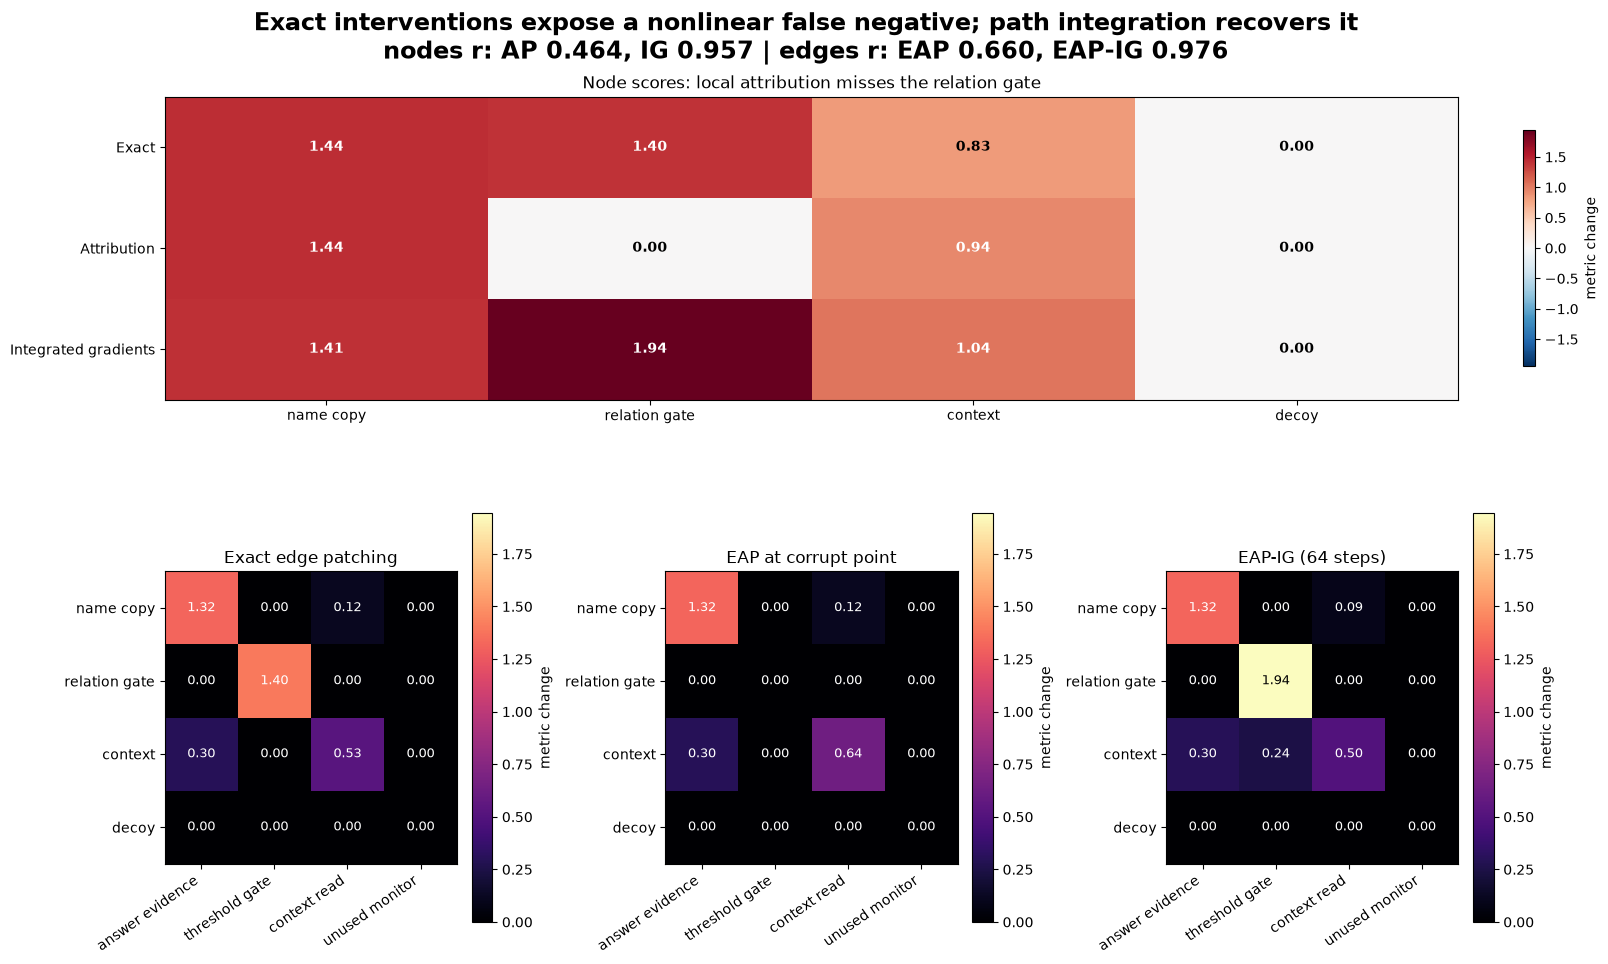

| Method | Pearson r vs exact | top-k overlap | Gradient cost |
|---|---:|---:|---:|
| Node AP | 0.464 | 0.500 | 1 backward |
| Node IG | 0.957 | 1.000 | 64 backwards |
| EAP | 0.660 | 0.667 | 1 backward |
| EAP-IG | 0.976 | 1.000 | 64 backwards |

Path-conservation error: nodes `0.000337`, edges `0.000337`. Linear positive control max error: `2.2e-16`. Shuffled-delta control: `r=-0.141`, top-3 overlap `0.000`.

In [9]:
def linear_positive_control(graph: PlantedAttributionGraph) -> float:
    """Verify first-order attribution is exact when the downstream metric is linear."""

    receiver_weights = t.tensor([1.2, 0.6, 0.8, 0.0], dtype=t.float64)

    def linear_metric(sender: t.Tensor) -> t.Tensor:
        return receiver_weights @ (graph.weights @ sender)

    baseline = linear_metric(graph.corrupt_sender)
    exact = []
    for index in range(graph.clean_sender.numel()):
        patched = graph.corrupt_sender.clone()
        patched[index] = graph.clean_sender[index]
        exact.append(linear_metric(patched) - baseline)
    sender = graph.corrupt_sender.clone().requires_grad_(True)
    gradient = t.autograd.grad(linear_metric(sender), sender)[0]
    attribution = (graph.clean_sender - graph.corrupt_sender) * gradient
    return float((t.stack(exact) - attribution).abs().max().item())

graph = make_planted_attribution_graph()
exact_nodes = exact_node_patch_effects(graph)
ap_nodes = first_order_node_attribution(graph)
ig_nodes = integrated_gradient_node_scores(graph, steps=64)

exact_edges = exact_edge_patch_effects(graph)
edge_deltas = planted_edge_deltas(graph)
corrupt_gradients = corrupt_receiver_gradients(graph)
path_receiver_gradients = receiver_path_gradients(graph, steps=64).mean(dim=0)
eap_edges = eap_edge_scores(edge_deltas, corrupt_gradients)
eap_ig_edges = eap_edge_scores(edge_deltas, path_receiver_gradients)

node_ap_metrics = agreement_metrics(exact_nodes, ap_nodes, top_k=2)
node_ig_metrics = agreement_metrics(exact_nodes, ig_nodes, top_k=2)
edge_eap_metrics = agreement_metrics(exact_edges, eap_edges, top_k=3)
edge_eap_ig_metrics = agreement_metrics(exact_edges, eap_ig_edges, top_k=3)

full_delta = float((toy_metric(graph, graph.clean_sender) - toy_metric(graph, graph.corrupt_sender)).item())
node_conservation_error = abs(float(ig_nodes.sum().item()) - full_delta)
edge_conservation_error = abs(float(eap_ig_edges.sum().item()) - full_delta)
linear_control_error = linear_positive_control(graph)

permutation = t.tensor([2, 0, 3, 1])
shuffled_edges = eap_edge_scores(edge_deltas[permutation], path_receiver_gradients)
shuffled_metrics = agreement_metrics(exact_edges, shuffled_edges, top_k=3)

node_matrix = t.stack([exact_nodes, ap_nodes, ig_nodes]).detach().numpy()
edge_matrices = [exact_edges, eap_edges, eap_ig_edges]
method_titles = ["Exact edge patching", "EAP at corrupt point", "EAP-IG (64 steps)"]

fig = plt.figure(figsize=(16, 10), constrained_layout=True)
grid = fig.add_gridspec(2, 3, height_ratios=[0.72, 1.35])

ax_nodes = fig.add_subplot(grid[0, :])
node_limit = float(np.abs(node_matrix).max())
im_nodes = ax_nodes.imshow(node_matrix, cmap="RdBu_r", vmin=-node_limit, vmax=node_limit, aspect="auto")
ax_nodes.set_xticks(range(4), graph.sender_labels)
ax_nodes.set_yticks(range(3), ["Exact", "Attribution", "Integrated gradients"])
ax_nodes.set_title("Node scores: local attribution misses the relation gate")
for row in range(node_matrix.shape[0]):
    for col in range(node_matrix.shape[1]):
        ax_nodes.text(col, row, f"{node_matrix[row, col]:.2f}", ha="center", va="center", color="white" if abs(node_matrix[row, col]) > 0.9 else "black", fontweight="bold")
fig.colorbar(im_nodes, ax=ax_nodes, shrink=0.78, label="metric change")

edge_limit = max(float(matrix.abs().max().item()) for matrix in edge_matrices)
for panel, (matrix, title) in enumerate(zip(edge_matrices, method_titles, strict=True)):
    ax = fig.add_subplot(grid[1, panel])
    array = matrix.detach().numpy()
    image = ax.imshow(array, cmap="magma", vmin=0.0, vmax=edge_limit)
    ax.set_xticks(range(4), graph.receiver_labels, rotation=35, ha="right")
    ax.set_yticks(range(4), graph.sender_labels)
    ax.set_title(title)
    for row in range(4):
        for col in range(4):
            value = array[row, col]
            ax.text(
                col,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="black" if value > 1.65 else "white",
                fontsize=9,
            )
    fig.colorbar(image, ax=ax, shrink=0.72, label="metric change")

fig.suptitle(
    "Exact interventions expose a nonlinear false negative; path integration recovers it\n"
    f"nodes r: AP {node_ap_metrics.correlation:.3f}, IG {node_ig_metrics.correlation:.3f} | "
    f"edges r: EAP {edge_eap_metrics.correlation:.3f}, EAP-IG {edge_eap_ig_metrics.correlation:.3f}",
    fontsize=17,
    fontweight="bold",
)

signature_path = assets_dir / "attribution_patching_eap_signature_result.png"
fig.savefig(signature_path, dpi=170, bbox_inches="tight", facecolor="white")
plt.show()

rows = [
    ("Node AP", node_ap_metrics.correlation, node_ap_metrics.topk_overlap, "1 backward"),
    ("Node IG", node_ig_metrics.correlation, node_ig_metrics.topk_overlap, "64 backwards"),
    ("EAP", edge_eap_metrics.correlation, edge_eap_metrics.topk_overlap, "1 backward"),
    ("EAP-IG", edge_eap_ig_metrics.correlation, edge_eap_ig_metrics.topk_overlap, "64 backwards"),
]
table = "| Method | Pearson r vs exact | top-k overlap | Gradient cost |\n|---|---:|---:|---:|\n"
table += "\n".join(f"| {name} | {corr:.3f} | {overlap:.3f} | {cost} |" for name, corr, overlap, cost in rows)
table += (
    f"\n\nPath-conservation error: nodes `{node_conservation_error:.6f}`, edges `{edge_conservation_error:.6f}`. "
    f"Linear positive control max error: `{linear_control_error:.1e}`. "
    f"Shuffled-delta control: `r={shuffled_metrics.correlation:.3f}`, top-3 overlap `{shuffled_metrics.topk_overlap:.3f}`."
)
display(Markdown(table))


<details>
<summary>Interpretation - what the figure establishes</summary>

- Exact node patching says the relation gate matters (`1.40`), but corrupt-point attribution assigns it zero.
- Node IG improves correlation from about `0.464` to `0.957` and top-2 overlap from `0.5` to `1.0`.
- Plain EAP reaches only `2/3` top-3 overlap; EAP-IG reaches `1.0` and raises edge correlation from about `0.660` to `0.976`.
- The linear positive control has numerical-zero error, so the implementation succeeds where first-order attribution should be exact.
- The shuffled-delta control has negative correlation and zero top-3 overlap, so the heatmap is not accepted merely for looking structured.

IG scores sum to the full path change. Single-node exact patch effects need not, because the threshold route creates interactions. This is why path completeness and single-patch agreement are shown as different metrics.

</details>


# Try It Yourself

Change the mechanism rather than only the plotting style. Lower `PLAY_GATE_STRENGTH`, move `PLAY_GATE_THRESHOLD`, or reduce `PLAY_IG_STEPS`. Predict when ordinary attribution stops producing a consequential false negative and when coarse integration changes the ranking.


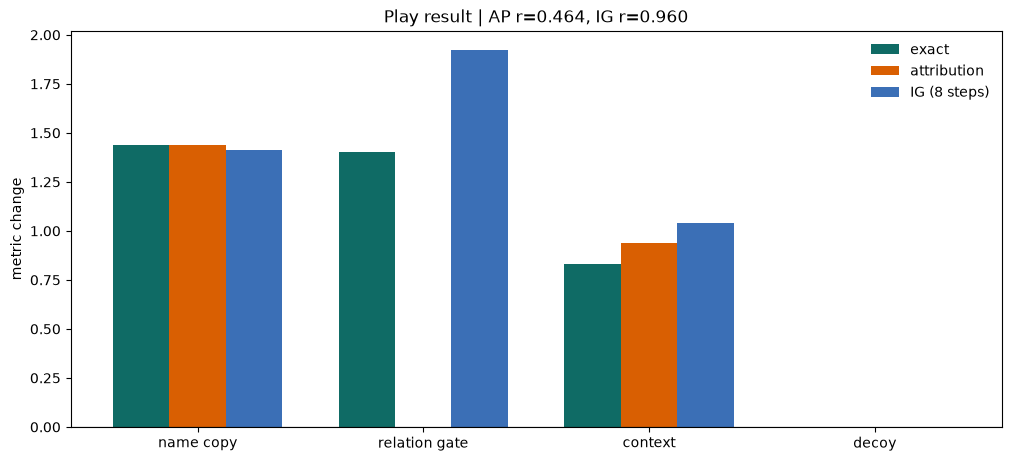

In [10]:
PLAY_GATE_STRENGTH = 1.4
PLAY_GATE_THRESHOLD = 1.0
PLAY_IG_STEPS = 8

play_graph = make_planted_attribution_graph(
    gate_strength=PLAY_GATE_STRENGTH,
    gate_threshold=PLAY_GATE_THRESHOLD,
)
play_exact = exact_node_patch_effects(play_graph)
play_ap = first_order_node_attribution(play_graph)
play_ig = integrated_gradient_node_scores(play_graph, steps=PLAY_IG_STEPS)
play_ap_report = agreement_metrics(play_exact, play_ap, top_k=2)
play_ig_report = agreement_metrics(play_exact, play_ig, top_k=2)

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
x = np.arange(len(play_graph.sender_labels))
width = 0.25
ax.bar(x - width, play_exact, width, label="exact", color="#0F6B65")
ax.bar(x, play_ap, width, label="attribution", color="#D95F02")
ax.bar(x + width, play_ig, width, label=f"IG ({PLAY_IG_STEPS} steps)", color="#3B6FB6")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x, play_graph.sender_labels)
ax.set_ylabel("metric change")
ax.set_title(
    f"Play result | AP r={play_ap_report.correlation:.3f}, "
    f"IG r={play_ig_report.correlation:.3f}"
)
ax.legend(frameon=False)
plt.show()


# Bonus Anomaly Hunt

Find a setting where integrated gradients has low path-conservation error but poor top-k agreement with exact single-node patching. This is possible because interacting nodes split path attribution even when the total is exact.

Suggested search:

```python
for threshold in t.linspace(0.2, 1.8, 17):
    for context_edge in t.linspace(0.0, 1.0, 11):
        # clone the graph, alter weights[1, 2], then compare:
        # 1. abs(IG.sum() - full clean-corrupt delta)
        # 2. agreement_metrics(exact, IG, top_k=2).topk_overlap
```

Write down the counterexample and explain which interaction makes exact single patches and joint-path attribution disagree. A low completeness error is not a certificate of causal localization.

# Real-model bridge

In TransformerLens, sender nodes become cached hook activations, receiver nodes become downstream hook inputs, and the scalar metric becomes an answer-token logit difference. The pinned release preflight uses `gelu-1l`, hook `blocks.0.hook_resid_post`, and a clean/corrupt prompt pair on CUDA. It checks exact residual-position patches against attribution and IG, but it is intentionally labeled a **mechanics preflight**: final-position localization on one prompt is not an IOI-scale EAP circuit discovery result.

The serialized release command is:

```bash
uv run python scripts/run_extension_verification_reports.py --section 8.2 --max-vram-gb 24.0
```

The exact command may be wrapped by the repository's release runner; the learner claim above does not depend on a stored report.

# Limitations

- The signature theorem is a small planted graph, not a trained transformer circuit.
- EAP-IG uses a straight-line activation path; off-manifold interpolation can mislead on real models.
- Integrated gradients guarantees path completeness under suitable numerical conditions, not agreement with every single-component intervention.
- The real-model bridge is not an IOI-scale EAP replication, AtP*, a distribution-wide circuit, or evidence that one prompt generalizes.
- Exact patching remains the ground truth for shortlisted nodes and edges whenever it is computationally feasible.

# Reading

- [Attribution Patching Outperforms Automated Circuit Discovery](https://arxiv.org/abs/2310.10348)
- [Edge Attribution Patching](https://arxiv.org/abs/2310.10348)
- [Integrated Gradients](https://arxiv.org/abs/1703.01365)
- [TransformerLens activation patching documentation](https://transformerlensorg.github.io/TransformerLens/generated/code/transformer_lens.patching.html)

The next section applies these accountability rules to automated circuit discovery. Keep exact interventions as the arbiter, not the gradient heatmap.


In [11]:
def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    from importlib import import_module

    backend = import_module("chapter8_automated_circuits.exercises.part2_attribution_patching_eap.solutions")
    return backend.run_gpu_test(max_vram_gb=max_vram_gb)


def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    from importlib import import_module

    backend = import_module("chapter8_automated_circuits.exercises.part2_attribution_patching_eap.solutions")
    return backend.run_full_experiment(max_vram_gb=max_vram_gb)
